# Session 17

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Task 1 — Dependent vs Independent Variable: YouTube Influencers

**Independent variable:** number of followers. **Dependent variable:** average monthly brand deals.

Followers is the variable that's measured first and treated as the input — it reflects an influencer's existing audience size, which isn't caused by how many brand deals they get. Brand deals, on the other hand, plausibly *depend on* follower count (brands look for reach when deciding who to pay), so it's the outcome we're trying to explain or predict — making it the dependent variable in this relationship.

## Task 2 — Scatter Plot: Myntra Ad Spend vs App Downloads (10 Points), with Line of Best Fit

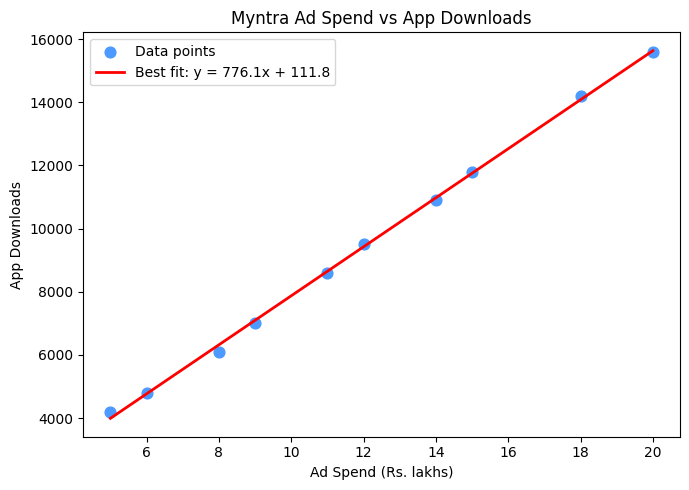

In [15]:
myntra_ad_spend = [5, 8, 12, 6, 15, 20, 9, 18, 11, 14]
myntra_downloads = [4200, 6100, 9500, 4800, 11800, 15600, 7000, 14200, 8600, 10900]

slope, intercept = np.polyfit(myntra_ad_spend, myntra_downloads, 1)
line_x = np.linspace(min(myntra_ad_spend), max(myntra_ad_spend), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(7, 5))
plt.scatter(myntra_ad_spend, myntra_downloads, color='#4c9aff', s=60, label='Data points')
plt.plot(line_x, line_y, color='red', linewidth=2, label=f'Best fit: y = {slope:.1f}x + {intercept:.1f}')
plt.title('Myntra Ad Spend vs App Downloads')
plt.xlabel('Ad Spend (Rs. lakhs)')
plt.ylabel('App Downloads')
plt.legend()
plt.tight_layout()
plt.show()

## Task 3 — scikit-learn: Predicting Swiggy Daily Orders from Ad Spend

In [16]:
swiggy_ad_spend = np.array([2, 3, 5, 4, 6, 8, 7, 9, 10, 12, 3.5, 6.5]).reshape(-1, 1)
swiggy_orders = np.array([320, 350, 410, 390, 460, 520, 500, 560, 610, 690, 365, 470])

model = LinearRegression()
model.fit(swiggy_ad_spend, swiggy_orders)

slope = model.coef_[0]
intercept = model.intercept_

print('Slope (coefficient):', slope)
print('Intercept:', intercept)

Slope (coefficient): 36.77924217462933
Intercept: 237.4814662273476


**What these mean:** the slope (**≈36.78**) says every extra ₹1 lakh spent on ads is associated with about **37 more average daily orders**. The intercept (**≈237.48**) is the model's predicted daily order count when ad spend is ₹0 — i.e., the baseline level of orders Swiggy would expect to see from organic demand alone, with no advertising.

## Task 4 — R-squared for the Swiggy Regression Model

In [17]:
predictions = model.predict(swiggy_ad_spend)
r_squared = r2_score(swiggy_orders, predictions)

print('R-squared:', r_squared)

R-squared: 0.9951027332397324


**Interpretation:** R² ≈ **0.995** is very close to 1, meaning about **99.5% of the variation** in daily orders in this sample is explained by ad spend alone. That points to a strong, almost purely linear relationship between the two — though a fit this clean on just 12 hand-built data points is also a sign this is simulated, noise-free data; real Swiggy data would almost certainly show more scatter and a lower R² once other factors (weather, day of week, competitor promotions) come into play.